In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

c:\Users\David\anaconda3\envs\stan\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
c:\Users\David\anaconda3\envs\stan\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Problem 2: Diffusion Model Explorations (8 points)
As extensively discussed in class, the drift-diffusion model (DDM) generates two response time (RT)
distributions, one for each boundary (i.e., lower and upper boundaries). This exercise asks you to
first explore a somewhat counterintuitive question about the basic DDM: What differences between
the means of the two RT distributions does the the model predict?
To approach this question from a simulation-based perspective, you need to repeatedly solve
the forward problem with different parameter configurations and collect the two summary statistics, namely, the two empirical means of the resulting RT distributions. First, choose a suitable
configuration of the four parameters and vary only the drift rates within a reasonable range (e.g.,
v ∈ [0.5 − 1.5]) for a total of 25 different drift rates. Make sure that your parameterizations can
generate a sufficient number of RTs for both distributions and you don’t end up with the process
only reaching the upper boundary. Second, for each of your parameter configurations, generate
N = 2000 synthetic observations and estimate the means of the two distributions. What do you
observe regarding the mean difference? Describe and interpret your results. (4 points)
In a similar spirit (keeping all parameters fixed and varying one), explore the effects of each of
the parameters on the means and standard deviations of the simulated RT distributions, quantify
and describe your results. (4 points)

In [2]:

def ddm_trial(v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """
    Simulates one realization of the diffusion process given
    a set of parameters and a step size `dt`.

    Parameters:
    -----------
    v     : float
        The drift rate (rate of information uptake)
    a     : float
        The boundary separation (decision threshold).
    beta  : float in [0, 1]
        Relative starting point (prior option preferences)
    tau   : float
        Non-decision time (additive constant)
    dt    : float, optional (default: 1e-3 = 0.001)
        The step size for the Euler algorithm.
    scale : float, optional (default: 1.0)
        The scale (sqrt(var)) of the Wiener process. Not considered
        a parameter and typically fixed to either 1.0 or 0.1.
    max_time: float, optional (default: .10)
        The maximum number of seconds before forced termination.

    Returns:
    --------
    (x, c) - a tuple of response time (y - float) and a 
        binary decision (c - int) 
    """

    # Your code here
    c = -1.
    y = beta * a
    num_steps = tau
    const= scale*np.sqrt(dt)
    
    while (y <= a and y >= 0) and num_steps <= max_time:
        
        z = np.random.randn()
        y += v * dt + const * z
        
        num_steps += dt
    
    if y>= a:
        c = 1.
    elif y <= 0:
        c = 0.
        
    return (round(num_steps, 3), c)



def ddm(num_sims, v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """Add a nice docstring."""

    data = np.zeros((num_sims, 2))
    for n in range(num_sims):
        data[n, :] = ddm_trial(v, a, beta, tau, dt, scale, max_time)
    return data



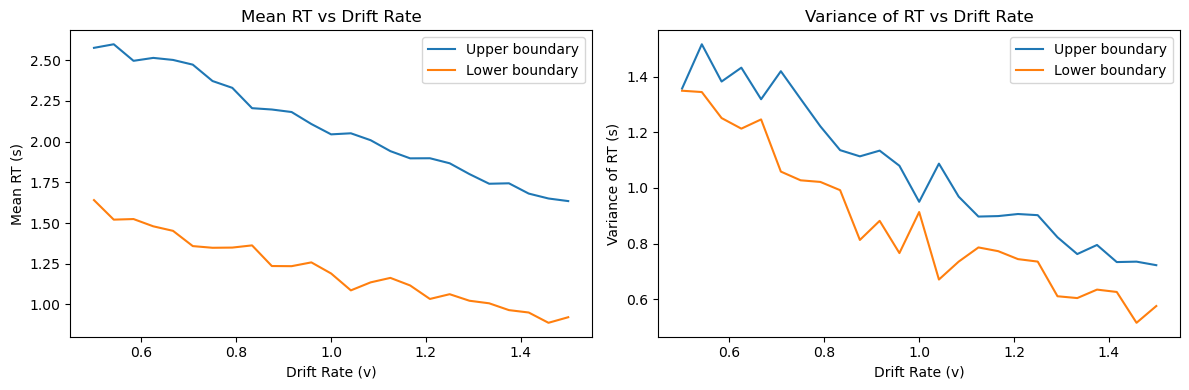

In [3]:
"""
Part 1
"""


drift_rates = np.linspace(0.5, 1.5, 25)

mean_rts_upper = []
mean_rts_lower = []

#Part 2
std_rts_upper = []
std_rts_lower = []

for v in drift_rates:
    
    # simulate 2000 trials
    simulation = ddm(2000, v, 3, 0.3, 0.3)
    
    # separate upper and lower hits
    rts_upper = simulation[:, 0][simulation[:, 1] == 1]
    rts_lower = simulation[:, 0][simulation[:, 1] == 0]
    
    # compute mean RT for each

    mean_rts_upper.append(np.mean(rts_upper))
    mean_rts_lower.append(np.mean(rts_lower))
    
    #Part 2
    #compute std RT for each
    std_rts_upper.append(np.std(rts_upper))
    std_rts_lower.append(np.std(rts_lower))


    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(drift_rates, mean_rts_upper, label='Upper boundary')
ax1.plot(drift_rates, mean_rts_lower, label='Lower boundary')
ax1.set_xlabel('Drift Rate (v)')
ax1.set_ylabel('Mean RT (s)')
ax1.set_title('Mean RT vs Drift Rate')
ax1.legend()

ax2.plot(drift_rates, std_rts_upper, label='Upper boundary')
ax2.plot(drift_rates, std_rts_lower, label='Lower boundary')
ax2.set_xlabel('Drift Rate (v)')
ax2.set_ylabel('Variance of RT (s)')
ax2.set_title('Variance of RT vs Drift Rate')
ax2.legend()

plt.tight_layout()
plt.show()


    
    
    

In [4]:
differences = np.array(mean_rts_lower) - np.array(mean_rts_upper)
print(f"First 5 differences: {differences[:5]}")
print(f"Last 5 differences: {differences[-5:]}")
print(f"Mean of first half: {differences[:12].mean():.3f}")
print(f"Mean of second half: {differences[12:].mean():.3f}")

First 5 differences: [-0.93547364 -1.07757719 -0.97225389 -1.03483014 -1.05013917]
Last 5 differences: [-0.734591   -0.77918942 -0.73071165 -0.76376289 -0.71355413]
Mean of first half: -0.983
Mean of second half: -0.802


In [6]:
print(f"Upper mean RT: {mean_rts_upper[0]:.3f}s at v = 0.5 -> {mean_rts_upper[-1]:.3f}s at v = 1.5")
print(f"Lower mean RT: {mean_rts_lower[0]:.3f}s at v = 0.5 -> {mean_rts_lower[-1]:.3f}s at v = 1.5")
print(f"Upper SD: {std_rts_upper[0]:.3f}s at v = 0.5 -> {std_rts_upper[-1]:.3f}s at v = 1.5")
print(f"Lower SD: {std_rts_lower[0]:.3f}s at v = 0.5 -> {std_rts_lower[-1]:.3f}s at v = 1.5")

Upper mean RT: 2.577s at v = 0.5 -> 1.635s at v = 1.5
Lower mean RT: 1.641s at v = 0.5 -> 0.921s at v = 1.5
Upper SD: 1.357s at v = 0.5 -> 0.723s at v = 1.5
Lower SD: 1.349s at v = 0.5 -> 0.576s at v = 1.5


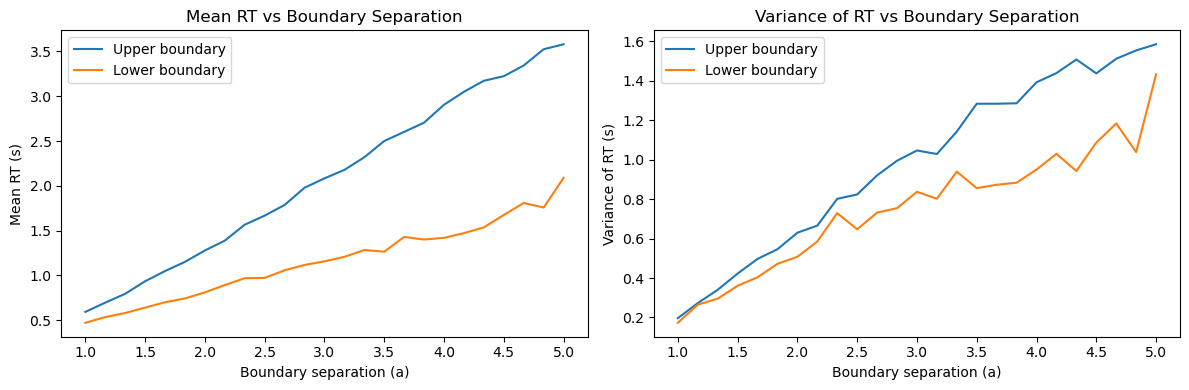

In [7]:
"""
Part 2: Varying Boundary Separation
"""

boundary_separation = np.linspace(1, 5, 25)

mean_rts_upper = []
mean_rts_lower = []

std_rts_upper = []
std_rts_lower = []

for a in boundary_separation:
    # simulate 2000 trials
    simulation = ddm(2000, 1, a, 0.3, 0.3)

    # separate upper and lower hits
    rts_upper = simulation[:, 0][simulation[:, 1] == 1]
    rts_lower = simulation[:, 0][simulation[:, 1] == 0]

    # compute mean RT for each

    mean_rts_upper.append(np.mean(rts_upper))
    mean_rts_lower.append(np.mean(rts_lower))

    #compute std RT for each
    std_rts_upper.append(np.std(rts_upper))
    std_rts_lower.append(np.std(rts_lower))
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(boundary_separation, mean_rts_upper, label='Upper boundary')
ax1.plot(boundary_separation, mean_rts_lower, label='Lower boundary')
ax1.set_xlabel('Boundary separation (a)')
ax1.set_ylabel('Mean RT (s)')
ax1.set_title('Mean RT vs Boundary Separation')
ax1.legend()

ax2.plot(boundary_separation, std_rts_upper, label='Upper boundary')
ax2.plot(boundary_separation, std_rts_lower, label='Lower boundary')
ax2.set_xlabel('Boundary separation (a)')
ax2.set_ylabel('Variance of RT (s)')
ax2.set_title('Variance of RT vs Boundary Separation')
ax2.legend()

plt.tight_layout()
plt.show()




In [8]:
print(f"Upper mean RT: {mean_rts_upper[0]:.3f}s at a = 1 -> {mean_rts_upper[-1]:.3f}s at a = 5")
print(f"Lower mean RT: {mean_rts_lower[0]:.3f}s at a = 1 -> {mean_rts_lower[-1]:.3f}s at a = 5")
print(f"Upper SD: {std_rts_upper[0]:.3f}s at a = 1 -> {std_rts_upper[-1]:.3f}s at a = 5")
print(f"Lower SD: {std_rts_lower[0]:.3f}s at a = 1 -> {std_rts_lower[-1]:.3f}s at a = 5")

Upper mean RT: 0.592s at a = 1 -> 3.581s at a = 5
Lower mean RT: 0.470s at a = 1 -> 2.089s at a = 5
Upper SD: 0.196s at a = 1 -> 1.585s at a = 5
Lower SD: 0.173s at a = 1 -> 1.433s at a = 5


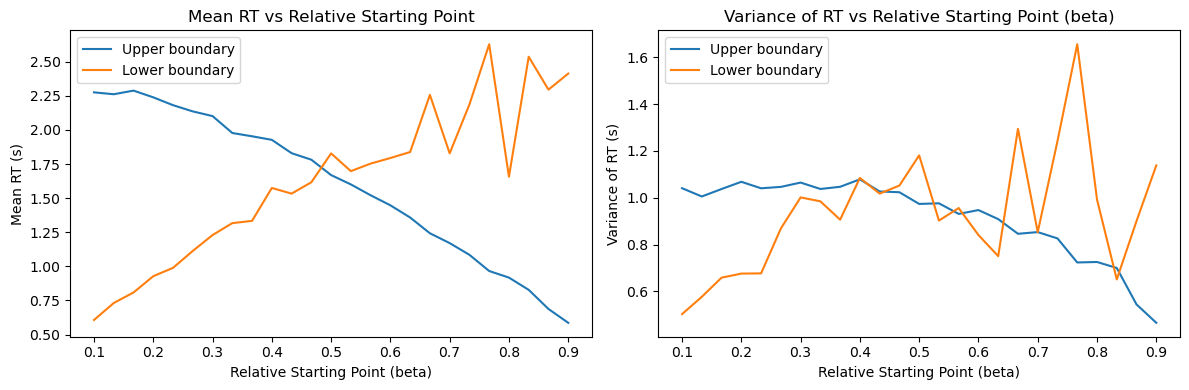

In [9]:
"""
Part 2: Varying Relative Starting Point
"""

betas = np.linspace(0.1, 0.9, 25)

mean_rts_upper = []
mean_rts_lower = []

std_rts_upper = []
std_rts_lower = []

for b in betas:
    # simulate 2000 trials
    simulation = ddm(2000, 1, 3, b, 0.3)

    # separate upper and lower hits
    rts_upper = simulation[:, 0][simulation[:, 1] == 1]
    rts_lower = simulation[:, 0][simulation[:, 1] == 0]

    # compute mean RT for each

    mean_rts_upper.append(np.mean(rts_upper))
    mean_rts_lower.append(np.mean(rts_lower))

    #compute std RT for each
    std_rts_upper.append(np.std(rts_upper))
    std_rts_lower.append(np.std(rts_lower))
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(betas, mean_rts_upper, label='Upper boundary')
ax1.plot(betas, mean_rts_lower, label='Lower boundary')
ax1.set_xlabel('Relative Starting Point (beta)')
ax1.set_ylabel('Mean RT (s)')
ax1.set_title('Mean RT vs Relative Starting Point')
ax1.legend()

ax2.plot(betas, std_rts_upper, label='Upper boundary')
ax2.plot(betas, std_rts_lower, label='Lower boundary')
ax2.set_xlabel('Relative Starting Point (beta)')
ax2.set_ylabel('Variance of RT (s)')
ax2.set_title('Variance of RT vs Relative Starting Point (beta)')
ax2.legend()

plt.tight_layout()
plt.show()




In [10]:
print(f"Upper mean RT: {mean_rts_upper[0]:.3f}s at beta = 0.1 -> {mean_rts_upper[-1]:.3f}s at beta = 0.9")
print(f"Lower mean RT: {mean_rts_lower[0]:.3f}s at beta = 0.1 -> {mean_rts_lower[-1]:.3f}s at beta = 0.9")
print(f"Upper SD: {std_rts_upper[0]:.3f}s at beta = 0.1 -> {std_rts_upper[-1]:.3f}s at beta = 0.9")
print(f"Lower SD: {std_rts_lower[0]:.3f}s at beta = 0.1 -> {std_rts_lower[-1]:.3f}s at beta = 0.9")

Upper mean RT: 2.276s at beta = 0.1 -> 0.586s at beta = 0.9
Lower mean RT: 0.607s at beta = 0.1 -> 2.414s at beta = 0.9
Upper SD: 1.041s at beta = 0.1 -> 0.465s at beta = 0.9
Lower SD: 0.502s at beta = 0.1 -> 1.138s at beta = 0.9


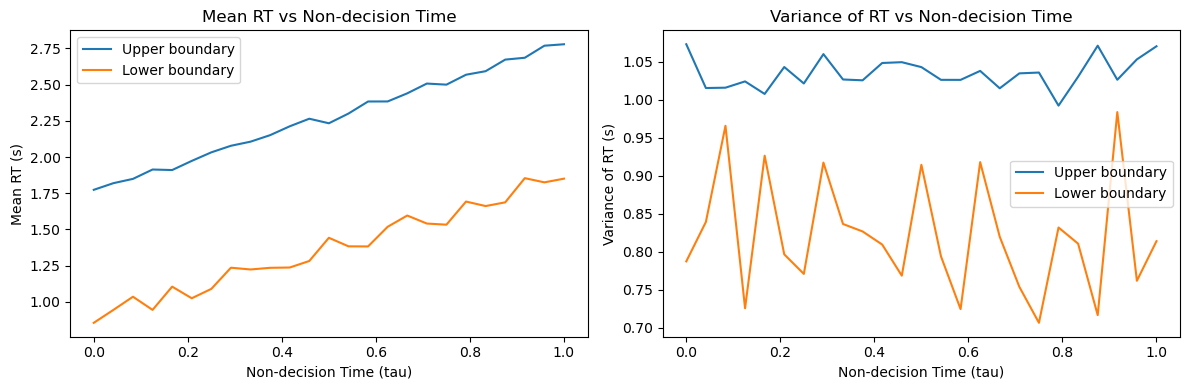

In [11]:
"""
Part 2: Varying Non-decision Time
"""

taus = np.linspace(0, 1, 25)

mean_rts_upper = []
mean_rts_lower = []

std_rts_upper = []
std_rts_lower = []

for t in taus:
    # simulate 2000 trials
    simulation = ddm(2000, 1, 3, 0.3, t)

    # separate upper and lower hits
    rts_upper = simulation[:, 0][simulation[:, 1] == 1]
    rts_lower = simulation[:, 0][simulation[:, 1] == 0]

    # compute mean RT for each

    mean_rts_upper.append(np.mean(rts_upper))
    mean_rts_lower.append(np.mean(rts_lower))

    #compute std RT for each
    std_rts_upper.append(np.std(rts_upper))
    std_rts_lower.append(np.std(rts_lower))
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(taus, mean_rts_upper, label='Upper boundary')
ax1.plot(taus, mean_rts_lower, label='Lower boundary')
ax1.set_xlabel('Non-decision Time (tau)')
ax1.set_ylabel('Mean RT (s)')
ax1.set_title('Mean RT vs Non-decision Time')
ax1.legend()

ax2.plot(taus, std_rts_upper, label='Upper boundary')
ax2.plot(taus, std_rts_lower, label='Lower boundary')
ax2.set_xlabel('Non-decision Time (tau)')
ax2.set_ylabel('Variance of RT (s)')
ax2.set_title('Variance of RT vs Non-decision Time')
ax2.legend()

plt.tight_layout()
plt.show()




In [12]:
print(f"Upper mean RT: {mean_rts_upper[0]:.3f}s at tau = 0 -> {mean_rts_upper[-1]:.3f}s at tau = 1")
print(f"Lower mean RT: {mean_rts_lower[0]:.3f}s at tau = 0 -> {mean_rts_lower[-1]:.3f}s at tau = 1")
print(f"Upper SD: {std_rts_upper[0]:.3f}s at tau = 0 -> {std_rts_upper[-1]:.3f}s at tau = 1")
print(f"Lower SD: {std_rts_lower[0]:.3f}s at tau = 0 -> {std_rts_lower[-1]:.3f}s at tau = 1")

Upper mean RT: 1.774s at tau = 0 -> 2.779s at tau = 1
Lower mean RT: 0.856s at tau = 0 -> 1.851s at tau = 1
Upper SD: 1.073s at tau = 0 -> 1.070s at tau = 1
Lower SD: 0.787s at tau = 0 -> 0.814s at tau = 1


## Problem 5: Simple Bayesian Regression with Stan 
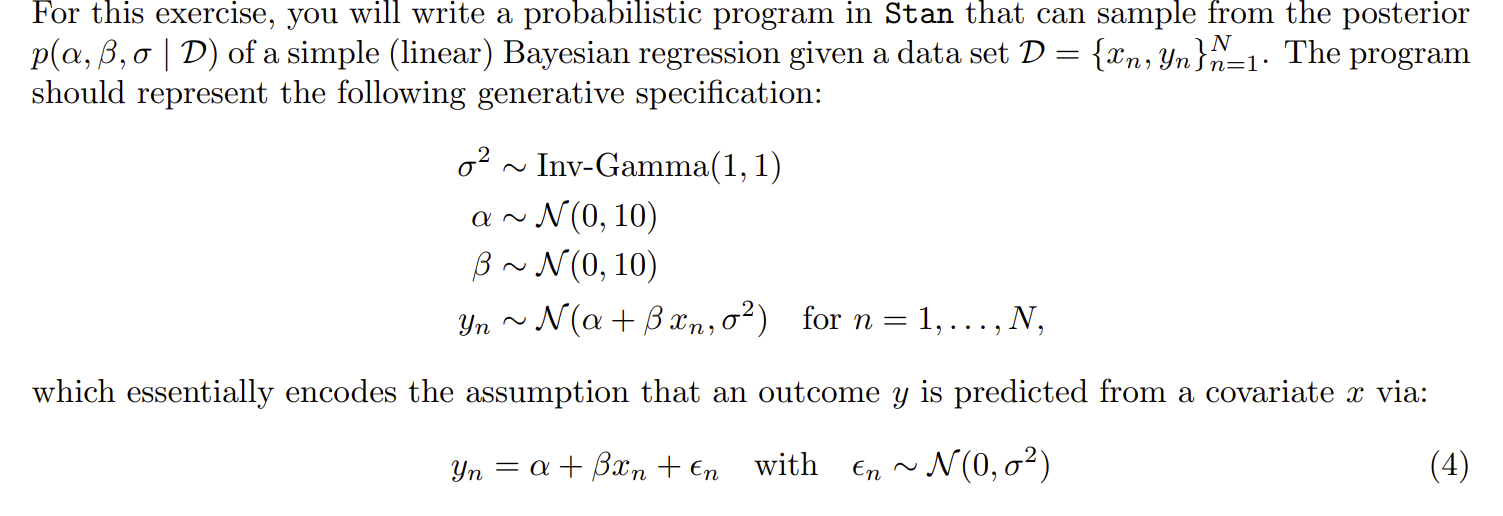
First, simulate a data set with fixed intercept (α), slope (β), and noise (σ) parameters of your
choosing, as well as a pre-set number of observations N.

Then, pass the data to your program, inspect convergence and efficiency diagnostics, and summarize
your inferential results both numerically and graphically.
• How accurate are the posterior means and how much uncertainty is left? (4 points)
• Repeat the analysis with ten times as many observations and report what happens to the
precision and uncertainty (2 points).

In [16]:
# Simulation

N = 10000
alpha = 1.7
beta = 2.2
sigma = 3.
noise = np.random.normal(size=N)

x = np.random.normal(size=N)
y = alpha + beta * x + sigma * noise


<Axes: ylabel='Count'>

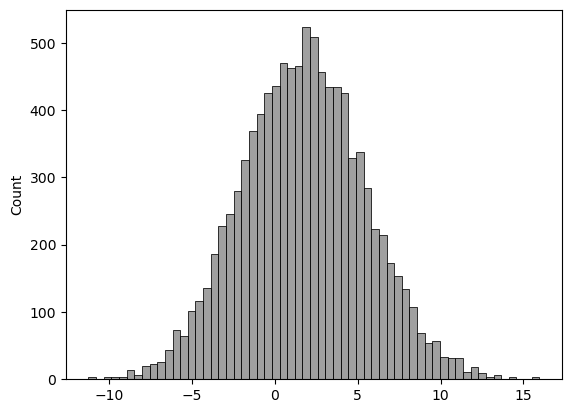

In [17]:
sns.histplot(y, color="gray")

In [ ]:
data_dict = {
    "N": N,
    "y": y,
    "x": x
}

model = CmdStanModel(model_name="problem5", stan_file="./model/problem5.stan")

14:33:41 - cmdstanpy - WARNING - CmdStanModel(model_name=...) is deprecated and will be removed in the next major version.
14:33:41 - cmdstanpy - INFO - compiling stan file C:\25-26_Coursework\cognitivemodeling\COGS4210\HW3\problem5.stan to exe file C:\25-26_Coursework\cognitivemodeling\COGS4210\HW3\problem5.exe
14:40:13 - cmdstanpy - INFO - compiled model executable: C:\25-26_Coursework\cognitivemodeling\COGS4210\HW3\problem5.exe


In [26]:
fit = model.sample(
    data = data_dict, 
    chains = 4, 
    iter_warmup=1000,
    iter_sampling = 1000
)

fit.summary()

14:41:01 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:00<00:09, 207.67it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:00<00:07, 238.99it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:01<00:06, 260.72it/s, (Warmup)]

chain 1:  20%|██        | 400/2000 [00:01<00:05, 274.92it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:01<00:05, 274.72it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:02<00:04, 291.54it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:02<00:04, 317.80it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:02<00:03, 329.78it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:02<00:03, 350.86it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:03<00:03, 328.27it/s, (Sampling)]




chain 1:  55%|█████▌    | 1100/2000 [00:03<00:02, 325.21it/s, (Sampling)]



chain 1:  60%|██████    | 1200/2000 [00:03<00:02, 334.82it/s, (Sampling)


14:41:08 - cmdstanpy - INFO - CmdStan done processing.
14:41:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
Consider re-running with show_console=True if the above output is unclear!


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-16020.40000,0.025321,1.179370,0.971103,-16022.70000,-16020.10000,-16019.10000,2167.72,2855.51,161.854,1.00180
sigma2,9.05551,0.001836,0.126347,0.125130,8.84697,9.05493,9.26537,4746.09,3240.18,354.371,1.00093
alpha,1.71201,0.000490,0.029587,0.029168,1.66284,1.71226,1.76028,3662.37,2691.56,273.454,1.00028
beta,2.20179,0.000459,0.029793,0.029312,2.15155,2.20170,2.25124,4230.30,2982.83,315.859,1.00032
sigma,3.00917,0.000305,0.020994,0.020769,2.97438,3.00914,3.04391,4746.09,3240.18,354.371,1.00094


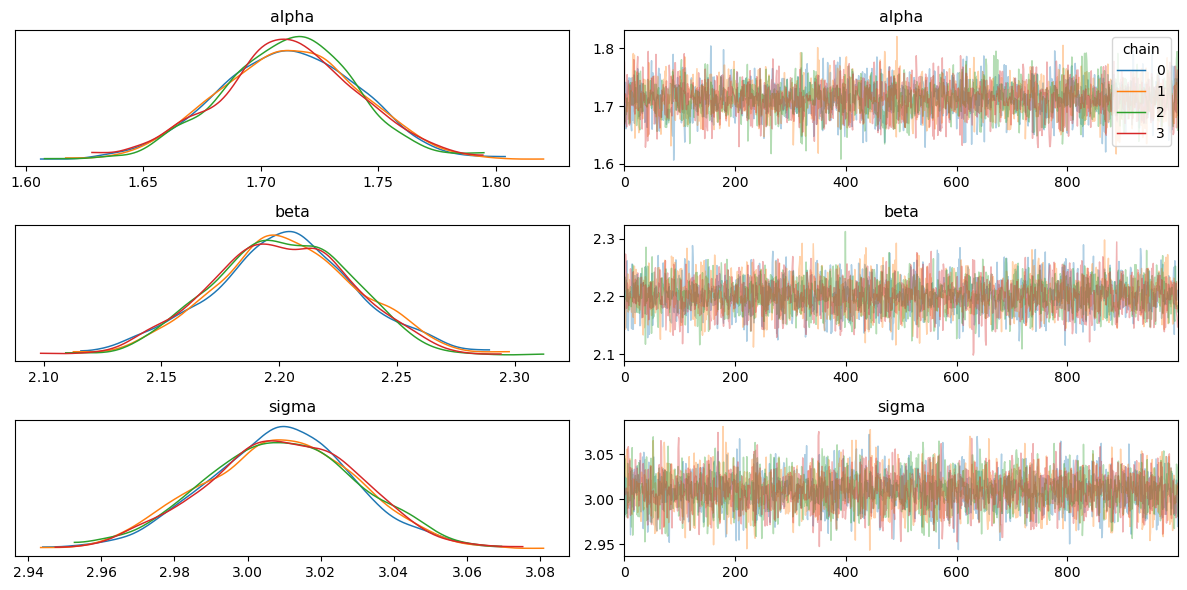

In [27]:
az.plot_trace(fit, var_names=['alpha', 'beta', 'sigma'], compact=False, legend=True)
plt.tight_layout()

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

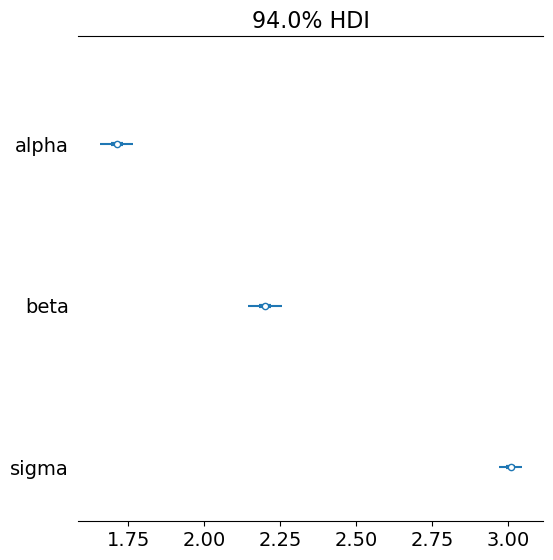

In [28]:
# Forest plots
az.plot_forest(fit, var_names=['alpha', 'beta', 'sigma'], combined=True)

In [30]:
#10 times the original sample
# Simulation 2

N = 10000 * 10
alpha = 1.7
beta = 2.2
sigma = 3.
noise = np.random.normal(size=N)

x = np.random.normal(size=N)
y = alpha + beta * x + sigma * noise

data_dict2 = {
    "N": N,
    "y": y,
    "x": x
}

fit = model.sample(
    data = data_dict2, 
    chains = 4, 
    iter_warmup=1000,
    iter_sampling = 1000
)

fit.summary()


16:20:38 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/2000 [00:00<13:50,  2.41it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:10<03:16,  9.65it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:22<03:21,  8.91it/s, (Warmup)]

chain 1:  15%|█▌        | 300/2000 [00:31<02:52,  9.85it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:46<02:08, 11.67it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:56<02:06, 11.04it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [01:08<02:13,  9.77it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [01:21<02:10,  9.19it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [01:32<02:00,  9.15it/s, (Warmup)]


chain 1:  50%|█████     | 1001/2000 [01:47<02:03,  8.10it/s, (Sampling)]







chain 1:  55%|█████▌    | 1100/2000 [02:02<01:59,  7.52it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [02:11<01:34,  8.50it/s, (Sampling)]



chai


16:23:51 - cmdstanpy - INFO - CmdStan done processing.
16:23:51 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'problem5.stan', line 23, column 8 to column 50)
Consider re-running with show_console=True if the above output is unclear!


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-159898.00000,0.029391,1.283290,1.008170,-159901.00000,-159898.00000,-159897.00000,1877.47,2424.13,6.18279,1.00215
sigma2,9.00613,0.000539,0.040649,0.039832,8.93814,9.00606,9.07225,5731.88,3072.87,18.87600,1.00036
alpha,1.69454,0.000169,0.009534,0.009746,1.67887,1.69461,1.70987,3208.91,3056.23,10.56740,1.00263
beta,2.18871,0.000153,0.009649,0.009475,2.17248,2.18874,2.20471,4005.27,2816.04,13.19000,1.00215
sigma,3.00101,0.000090,0.006772,0.006641,2.98967,3.00101,3.01202,5731.88,3072.87,18.87600,1.00035


## Problem 6: Estimating the Drift-Diffusion Model
Using your knowledge of the interpretation of the four key diffusionmodel parameters, you will perform a model-based analysis to disentangle the two conditions by
estimating the DDM parameters. Which parameter best reflects task difficulty (i.e., the quality and rate of information accumulation)? Once you answer this question, you will know which parameter should vary between conditions. Your task is to complete the Stan program provided in diffusion multiple.stan, solve the inverse problem from the data, and determine which indicator in condition corresponds to the high-interference (difficult) field based on your posterior estimates (6 points). Along the way, you must ensure computational faithfulness by reporting and interpreting convergence and efficiency diagnostics (2 points).


In [ ]:
model = CmdStanModel(model_name='diffusion_multiple', stan_file='./model/diffusion_multiple.stan')

16:28:52 - cmdstanpy - WARNING - CmdStanModel(model_name=...) is deprecated and will be removed in the next major version.
16:28:53 - cmdstanpy - INFO - compiling stan file C:\25-26_Coursework\cognitivemodeling\COGS4210\HW3\diffusion_multiple.stan to exe file C:\25-26_Coursework\cognitivemodeling\COGS4210\HW3\diffusion_multiple.exe
16:35:03 - cmdstanpy - INFO - compiled model executable: C:\25-26_Coursework\cognitivemodeling\COGS4210\HW3\diffusion_multiple.exe


In [6]:
data = pd.read_csv("./data/response_times.csv", sep=";", header= 0)

In [13]:
data_dict = {
    "N": len(data),
    "J": data.id.nunique(),
    "id": data.id.values,
    "y": data.rt.values,
    "condition": data.condition.values,
    "choice": data.choice.values
    
}

fit = model.sample(
    data=data_dict,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000
)

17:13:13 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:02<00:52, 36.36it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:04<00:35, 50.06it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:05<00:27, 61.39it/s, (Warmup)]




chain 1:  20%|██        | 400/2000 [00:06<00:22, 71.26it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:07<00:19, 75.82it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:08<00:16, 84.57it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:09<00:14, 91.30it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:10<00:12, 95.74it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:11<00:10, 103.46it/s, (Warmup)]

chain 1:  50%|█████     | 1000/2000 [00:14<00:17, 55.97it/s, (Sampling)]




chain 1:  55%|█████▌    | 1100/2000 [00:18<00:21, 42.69it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:22<00:21, 36.52it/s, (Sampling)]


cha


17:14:01 - cmdstanpy - INFO - CmdStan done processing.
17:14:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 53, column 8 to column 27)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 53, column 8 to column 27)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 53, column 8 to column 27)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 53, column 8 to column 27)
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'diffusion_multiple.stan', line 53, column 8 to column 27)
	Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'diffusion_multiple.stan', line 53, column 8 to column 27)
	Exception: gamma_lpdf: Random variable is i

In [14]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-38.527900,0.086710,3.604210,3.544700,-44.809500,-38.221200,-33.196000,1707.43,2588.96,12.7097,1.003350
"v[1,1]",0.850033,0.003031,0.158340,0.156979,0.588262,0.849313,1.111550,2764.21,2903.63,20.5762,1.001960
"v[1,2]",3.620780,0.005257,0.317822,0.320139,3.097240,3.615180,4.134050,3706.46,2980.63,27.5902,1.001760
"v[2,1]",0.721339,0.003436,0.201479,0.201174,0.390872,0.723359,1.065100,3456.57,3096.97,25.7300,1.000990
"v[2,2]",3.856710,0.006235,0.408729,0.419462,3.173390,3.857390,4.512500,4301.81,3065.11,32.0218,1.000430
"v[3,1]",0.652416,0.003344,0.218092,0.216063,0.291402,0.651302,1.014650,4268.85,3195.35,31.7765,1.000050
"v[3,2]",3.455580,0.006124,0.408898,0.411607,2.785600,3.461210,4.103620,4527.72,3056.77,33.7034,1.000170
"v[4,1]",0.464921,0.003572,0.206887,0.206339,0.125726,0.465559,0.802354,3400.72,3058.72,25.3143,1.000530
"v[4,2]",3.391980,0.006478,0.392999,0.393679,2.761690,3.393150,4.033660,3723.52,2850.78,27.7171,1.000690
"v[5,1]",0.261173,0.003512,0.216872,0.215754,-0.102174,0.264796,0.616685,3831.23,2959.15,28.5189,1.001190
